In [1]:
%pip install -q -U ultralytics huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 8.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import gc
import json
import time
import cv2
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn.functional as F
from zipfile import ZipFile

from scipy.optimize import linear_sum_assignment
from huggingface_hub import hf_hub_download
from ultralytics.models.sam import SAM3SemanticPredictor

In [5]:

DATASET_URL = (
    "https://github.com/ultralytics/"
    "assets/releases/download/v0.0.0/"
    "crack-seg.zip"
)

DATASETS_ROOT = Path("/content/datasets")
ARCHIVE_PATH = DATASETS_ROOT / "crack-seg.zip"
DATASET_ROOT = DATASETS_ROOT / "crack-seg"

DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
EXPECTED_COUNTS = {"train": 3717, "val": 200, "test": 112}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

dataset_ready = (DATASET_ROOT / "images" / "train").is_dir()

if not dataset_ready:
    if not ARCHIVE_PATH.is_file():
        torch.hub.download_url_to_file(
            DATASET_URL, str(ARCHIVE_PATH), progress=True
        )

    with ZipFile(ARCHIVE_PATH, "r") as zip_file:
        zip_file.extractall(DATASETS_ROOT)


if not DATASET_ROOT.is_dir():
    candidates = [
        path for path in DATASETS_ROOT.rglob("*")
        if path.is_dir() and (path / "images").is_dir() and "crack" in path.name.lower()
    ]

    if len(candidates) != 1:
        candidates = [
            path for path in DATASETS_ROOT.rglob("images")
            if path.is_dir()
        ]
        if len(candidates) == 1:
            candidates = [candidates[0].parent]


    DATASET_ROOT = candidates[0]

for split in SPLITS:
    required_directories = [
        (DATASET_ROOT / "images" / split),
        (DATASET_ROOT / "labels" / split)
    ]
    
    for directory in (required_directories):
        if not directory.is_dir():
            raise FileExistsError(directory)

print("Dataset extracted:", DATASET_ROOT)

100%|██████████| 91.6M/91.6M [00:01<00:00, 80.7MB/s]


Dataset extracted: /content/datasets


In [6]:
VAL_IMAGES_DIR = DATASET_ROOT / "images" / "val"
VAL_LABELS_DIR = DATASET_ROOT / "labels" / "val"

BLOCK_05_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_05"
)

SAM3_OUTPUT_ROOT = BLOCK_05_ROOT / "sam3_demo"
SAM3_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = 0

print("GPU:", torch.cuda.get_device_name(0))
print( "Validation images:", VAL_IMAGES_DIR)

GPU: Tesla T4
Validation images: /content/datasets/images/val


**Download gated weight once**

In [8]:
model = hf_hub_download(
    repo_id="facebook/sam3",
    filename="sam3.pt",
    token="HF_token"
)

print("Model:", model)

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

Model: /root/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt


**Initialize SAM3**

In [9]:
sam3_overrides = {
    "conf": 0.25,
    "task": "segment",
    "mode": "predict",
    "model" : model,
    "imgsz" : 1008,
    "quantize" : 16,
    "device" : DEVICE,
    "save": False,
    "verbose": False,
}

sam3_predictor = SAM3SemanticPredictor(overrides=sam3_overrides)

### Ground-truth preparation

**Polygon labels to instance masks**

In [10]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png",}

def find_validation_images():
    return sorted(
        path for path in VAL_IMAGES_DIR.iterdir()
        if (
            path.is_file() and path.suffix.lower() 
            in IMAGE_SUFFIXES
        )
    )

In [11]:
def load_ground_truth_instances(image_path):
    image_bgr = cv2.imread(str(image_path))
    height, width = image_bgr.shape[:2]
    
    label_path = (
        VAL_LABELS_DIR / f"{image_path.stem}.txt"
    )

    instance_masks = []
    instance_boxes = []

    if not label_path.is_file():
        return (
            image_bgr, instance_masks, instance_boxes,
        )

    lines = label_path.read_text(encoding="utf-8").splitlines()

    for line in lines:
        values = line.split()

        if len(values) < 7:
            continue

        coordinates = np.asarray(values[1:], dtype=np.float32,
        ).reshape(-1, 2)

        pixel_points = (
            coordinates
            * np.asarray([width, height],dtype=np.float32)
        )

        pixel_points[:, 0] = np.clip(
            pixel_points[:, 0],
            0, width - 1,
        )

        pixel_points[:, 1] = np.clip(
            pixel_points[:, 1],
            0, height - 1,
        )

        pixel_points = np.rint(pixel_points).astype(np.int32)
        mask = np.zeros((height, width), dtype=np.uint8)

        cv2.fillPoly(mask, [pixel_points], 1)
        if mask.sum() == 0:
            continue

        ys, xs = np.where(mask > 0)

        box = [
            float(xs.min()), float(ys.min()),
            float(xs.max() + 1), float(ys.max() + 1),
        ]

        instance_masks.append(mask.astype(bool))
        instance_boxes.append(box)

    return (
        image_bgr,
        instance_masks,
        instance_boxes
    )

**Select six validation images**

In [12]:
all_records = []

for image_path in find_validation_images():
    image_bgr, gt_masks, gt_boxes = load_ground_truth_instances(
        image_path
    )

    if not gt_masks:
        continue
    
    all_records.append(
        {
            "image_path": image_path,
            "gt_masks": gt_masks,
            "gt_boxes": gt_boxes,
            "instances": len(gt_masks)
        }
    )

In [13]:
rng = np.random.default_rng(42)

multi_records = [
    record for record in all_records
    if record["instances"] >= 2
]

single_records = [
    record for record in all_records
    if record["instances"] == 1
]

def random_take(records, count):
    if not records:
        return []
    
    count = min(count, len(records))
    indices = rng.choice(len(records), size=count, replace=False)
    
    return [records[index] for index in indices]

In [14]:
selected_records = (
    random_take(multi_records, 4)
    + random_take(single_records, 2)
)

if len(selected_records) < 6:

    selected_paths = {
        record["image_path"] for record in selected_records
    }

    remaining = [
        record for record in all_records
        if record["image_path"] not in selected_paths
    ]

    selected_records.extend(
        random_take(remaining, 6 - len(selected_records))
    )

In [15]:
selected_manifest = pd.DataFrame(
    [
        {
            "image": record["image_path"].name,
            "instances": record["instances"]
        }
        for record in selected_records
    ]
)

selected_manifest_path = SAM3_OUTPUT_ROOT / "sam3_selected_images.csv"
selected_manifest.to_csv(selected_manifest_path, index=False)

selected_manifest

,image,instances
0,2122.rf.4ed10b8ba9d48f3c0abfac28e1ff22c7.jpg,2
1,1658.rf.38d44ec0dfa198d017ba9cb0ada57f15.jpg,2
2,2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg,9
3,2537.rf.8d6b4c731839518a75f5a8b6f937a424.jpg,2
4,2099.rf.ec1ed05c1f6b723618a43490789d2ad5.jpg,1
5,3228.rf.2bc533ca5e879aecb669ac56ea1c2373.jpg,1


### Instance evaluation

**Prediction extraction and matching**

In [16]:
def synchronize_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
def extract_predictions(results, target_height, target_width):
    if isinstance(results, (list, tuple)):
        result = results[0]
    else:
        result = results
    
    
    if result is None or result.masks is None:
        empty_masks = np.zeros(
            (0, target_height, target_width,), dtype=bool
        )

        return (
            empty_masks, np.asarray([], dtype=np.float32)
        )
    
    masks = result.masks.data.detach().float()
    
    if masks.ndim == 2:
        masks = masks.unsqueeze(0)
    
    if masks.shape[-2:] != (
        target_height,
        target_width,
    ):
        masks = F.interpolate(
            masks.unsqueeze(1),
            size=(
                target_height, target_width
            ),
            mode="nearest",
        ).squeeze(1)

    masks = (masks > 0.5).cpu().numpy()
    
    if result.boxes is not None and result.boxes.conf is not None:
        scores = result.boxes.conf.detach().float().cpu().numpy()
        
    else:
        scores = np.full(len(masks), np.nan, dtype=np.float32)

    return (masks.astype(bool), scores)

In [17]:
def mask_iou(first_mask, second_mask):
    intersection = np.logical_and(first_mask, second_mask).sum()
    union = np.logical_or(first_mask, second_mask).sum()
    
    return (
        float(intersection / union) if union > 0 else 0.0
    )

In [18]:
def evaluate_instances(predicted_masks, ground_truth_masks, exemplar_gt_index=None, iou_threshold=0.50):
    predicted_count = len(predicted_masks)
    ground_truth_count = len(ground_truth_masks)
    
    iou_matrix = np.zeros(
        (predicted_count, ground_truth_count),
        dtype=np.float32
    )
    
    for prediction_index in range(predicted_count):
        for gt_index in range(ground_truth_count):
            iou_matrix[prediction_index, gt_index] = mask_iou(
                predicted_masks[prediction_index],
                ground_truth_masks[gt_index]
            )
    
    matched_ious = np.asarray([], dtype=np.float32)
    matched_gt_indices = np.asarray([], dtype=np.int64)
    
    if (predicted_count > 0 and ground_truth_count > 0):
        prediction_indices, gt_indices = (
            linear_sum_assignment(-iou_matrix)
        )
        matched_ious = iou_matrix[prediction_indices,gt_indices]

        accepted = (matched_ious>= iou_threshold)
        matched_gt_indices = gt_indices[accepted]
        
        true_positives = int(accepted.sum())
    
    else:
        true_positives = 0
    
    false_positives = predicted_count - true_positives
    false_negatives = ground_truth_count - true_positives
    
    precision = (
        true_positives / (true_positives + false_positives)
        if (true_positives + false_positives) > 0 else 0.0
    )
    recall = (
        true_positives / (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0 else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )
    mean_gt_iou = (
        float(matched_ious.sum() / ground_truth_count)
        if ground_truth_count > 0 else 0.0
    )
    unprompted_recall = np.nan
    
    if exemplar_gt_index is not None and ground_truth_count > 1:
        matched_unprompted = sum(
            int(gt_index) != exemplar_gt_index
            for gt_index in matched_gt_indices
        )

        unprompted_recall =  matched_unprompted/ (ground_truth_count - 1)
    
    return {
        "tp": true_positives,
        "fp": false_positives,
        "fn": false_negatives,
        "precision_50": precision,
        "recall_50": recall,
        "f1_50": f1,
        "mean_gt_iou": mean_gt_iou,
        "image_success": float(true_positives > 0),
        "unprompted_recall_50": (unprompted_recall)
    }

**Warm-up**

In [20]:
warmup_record = selected_records[0]

sam3_predictor.set_image(
    str(warmup_record["image_path"])
)

_ = sam3_predictor(text=["crack"])

synchronize_cuda()

**Text and exemplar experiment**

In [21]:
TEXT_PROMPTS = [
    "crack",
    "surface crack",
    "thin crack",
]

metric_rows = []
prediction_cache = {}
exemplar_boxes = {}

for record in selected_records:
    image_path = record["image_path"]

    image_bgr = cv2.imread(str(image_path))
    height, width = image_bgr.shape[:2]

    synchronize_cuda()
    encoding_start = time.perf_counter()

    sam3_predictor.set_image(str(image_path))

    synchronize_cuda()
    encoding_ms = (time.perf_counter() - encoding_start) * 1000
    
    for prompt in TEXT_PROMPTS:
        synchronize_cuda()
        query_start = time.perf_counter()
        
        results = sam3_predictor(text=[prompt])
        synchronize_cuda()
        
        query_ms = (time.perf_counter() - query_start) * 1000
        
        predicted_masks, scores = extract_predictions(results, height, width)
        evaluation = evaluate_instances(predicted_masks, record["gt_masks"])
        
        method = (f"text: {prompt}")
        prediction_cache[(image_path.name, method)] = predicted_masks
        
        metric_rows.append(
        {
            "image": image_path.name,
            "method": method,
            "gt_instances": len(record["gt_masks"]),
            "predicted_instances": len(predicted_masks),
            "mean_score": (
                float(np.nanmean(scores)) if len(scores) > 0 else np.nan
            ),
            "encoding_ms": encoding_ms,
            "query_ms": query_ms,
            **evaluation,
        })
    
    masks_sizes = [mask.sum() for mask in record["gt_masks"]]
    exemplar_gt_index = int(np.argmax(masks_sizes))
    
    exemplar_box = record["gt_boxes"][exemplar_gt_index]
    exemplar_boxes[image_path.name] = exemplar_box
    synchronize_cuda()
    
    query_start = time.perf_counter()
    
    results = sam3_predictor(
        bboxes = [exemplar_box]
    )
    synchronize_cuda()
    
    query_ms = (time.perf_counter() - query_start) * 1000
    predicted_masks, scores = extract_predictions(
        results, height, width
    )

    evaluation = evaluate_instances(
        predicted_masks,
        record["gt_masks"],
        exemplar_gt_index=exemplar_gt_index,
    )
    
    method = "exemplar"
    prediction_cache[(image_path.name, method)] = predicted_masks
    
    metric_rows.append(
        {
            "image": image_path.name,
            "method": method,
            "gt_instances": len(record["gt_masks"]),
            "predicted_instances": len(predicted_masks),
            "mean_score": (
                float(np.nanmean(scores)) if len(scores) > 0 else np.nan
            ),
            "encoding_ms": encoding_ms,
            "query_ms": query_ms,
            **evaluation,
        }
    )

    print(image_path.name, "complete")

2122.rf.4ed10b8ba9d48f3c0abfac28e1ff22c7.jpg complete
1658.rf.38d44ec0dfa198d017ba9cb0ada57f15.jpg complete
2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg complete
2537.rf.8d6b4c731839518a75f5a8b6f937a424.jpg complete
2099.rf.ec1ed05c1f6b723618a43490789d2ad5.jpg complete
3228.rf.2bc533ca5e879aecb669ac56ea1c2373.jpg complete


**Metrics and prompt summary**

In [22]:
sam3_metrics = pd.DataFrame(metric_rows)
metrics_path = SAM3_OUTPUT_ROOT / "sam3_prompt_metrics.csv"
sam3_metrics.to_csv(
    metrics_path,
    index=False,
)

In [ ]:
summary_rows = []

for method, group in sam3_metrics.groupby(
    "method"
):

    tp = int(group["tp"].sum())
    fp = int(group["fp"].sum())
    fn = int(group["fn"].sum())

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * tp
        / (2 * tp + fp + fn)
        if (2 * tp + fp + fn) > 0
        else 0.0
    )

    unprompted_values = (
        group["unprompted_recall_50"]
        .dropna()
    )

    summary_rows.append(
        {
            "method": method,
            "images": len(group),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision_50": precision,
            "recall_50": recall,
            "f1_50": f1,
            "mean_gt_iou": group[
                "mean_gt_iou"
            ].mean(),
            "image_success_rate": group[
                "image_success"
            ].mean(),
            "mean_query_ms": group[
                "query_ms"
            ].mean(),
            "mean_encoding_ms": group[
                "encoding_ms"
            ].mean(),
            "unprompted_recall_50": (
                unprompted_values.mean()
                if len(unprompted_values) > 0
                else np.nan
            ),
        }
    )


In [28]:
sam3_summary = pd.DataFrame(summary_rows).sort_values(
    "f1_50", ascending=False
)

summary_path = (
    SAM3_OUTPUT_ROOT
    / "sam3_prompt_summary.csv"
)

sam3_summary.to_csv(
    summary_path,
    index=False,
)

sam3_summary

,method,images,tp,fp,fn,precision_50,recall_50,f1_50,mean_gt_iou,image_success_rate,mean_query_ms,mean_encoding_ms,unprompted_recall_50
0,exemplar,6,6,24,11,0.200000,0.352941,0.255319,0.514663,0.833333,168.886747,405.880486,0.28125
2,text: surface crack,6,4,25,13,0.137931,0.235294,0.173913,0.490151,0.666667,148.440204,405.880486,NaN
1,text: crack,6,5,42,12,0.106383,0.294118,0.156250,0.497881,0.833333,147.462817,405.880486,NaN
3,text: thin crack,6,4,35,13,0.102564,0.235294,0.142857,0.498994,0.666667,148.237932,405.880486,NaN


**Qualitative comparison**

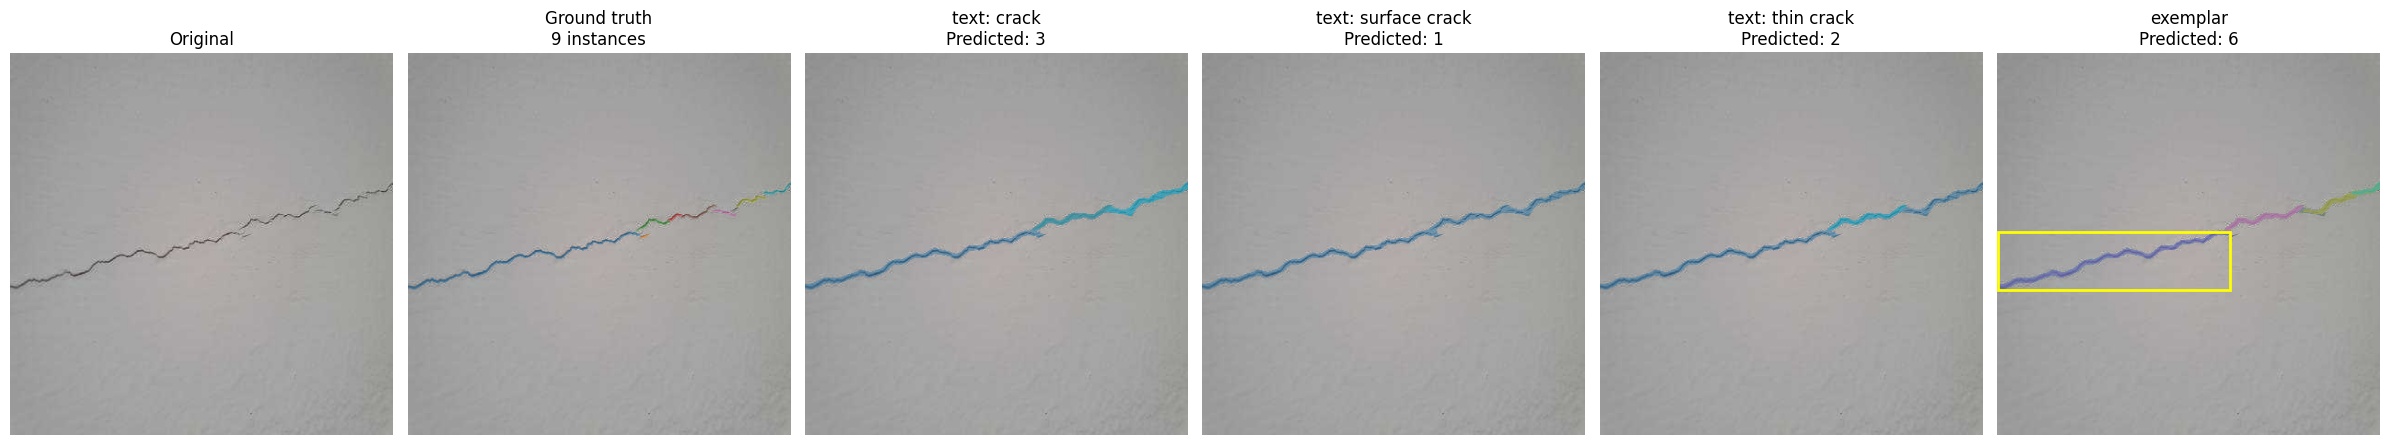

In [25]:
def overlay_instances(
    image_rgb,
    masks,
):
    canvas = image_rgb.astype(np.float32) / 255.0
    colors = plt.cm.tab10(
        np.linspace(0, 1, max(len(masks), 1))
    )[:, :3]

    for index, mask in enumerate(masks):
        canvas[mask] = 0.55 * canvas[mask] + 0.45 * colors[index]

    return np.clip(canvas, 0, 1)


visual_record = max(
    selected_records,
    key=lambda record: record["instances"],
)

visual_image_path = visual_record["image_path"]

visual_image_rgb = cv2.cvtColor(
    cv2.imread(str(visual_image_path)),
    cv2.COLOR_BGR2RGB,
)

methods = [
    "text: crack",
    "text: surface crack",
    "text: thin crack",
    "exemplar",
]

figure, axes = plt.subplots(1, 6, figsize=(24, 5))

axes[0].imshow(visual_image_rgb)
axes[0].set_title("Original")

axes[1].imshow(
    overlay_instances(
        visual_image_rgb,
        visual_record["gt_masks"],
    )
)
axes[1].set_title(
    "Ground truth\n"
    f"{visual_record['instances']} instances"
)

for axis, method in zip(
    axes[2:],
    methods
):
    predicted_masks = prediction_cache[
        (visual_image_path.name, method)
    ]

    axis.imshow(
        overlay_instances(
            visual_image_rgb,
            predicted_masks,
        )
    )

    axis.set_title(
        f"{method}\n"
        f"Predicted: {len(predicted_masks)}"
    )

    if method == "exemplar":
        x1, y1, x2, y2 = exemplar_boxes[
            visual_image_path.name
        ]

        rectangle = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            color="yellow",
            linewidth=2,
        )

        axis.add_patch(rectangle)

for axis in axes:
    axis.axis("off")

figure.tight_layout()

comparison_figure_path = (
    SAM3_OUTPUT_ROOT / "sam3_prompt_comparison.png"
)

figure.savefig(
    comparison_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [ ]:
text_only_summary = sam3_summary[
    sam3_summary["method"].str.startswith("text:")
]

best_text_row = text_only_summary.sort_values(
    "f1_50", ascending=False
).iloc[0]

block_05b_report = {
    "model": "sam3.pt",
    "task": "promptable concept segmentation",
    "validation_images": len(selected_records),
    "text_prompts": TEXT_PROMPTS,
    "confidence_threshold": 0.25,
    "iou_match_threshold": 0.50,
    "best_text_prompt": best_text_row["method"],
    "best_text_f1_50": float(best_text_row["f1_50"]),
    "summary": json.loads(sam3_summary.to_json(orient="records")),
    "test_split_used": False,
}

report_path = SAM3_OUTPUT_ROOT / "block_05b_report.json"

report_path.write_text(
    json.dumps(
        block_05b_report,
        indent=2
    ),
    encoding="utf-8"
)

print("=" * 60)
print("BLOCK 5B COMPLETE")
print("=" * 60)

print("Best text prompt:", block_05b_report["best_text_prompt"])
print("Best text F1@0.50:", round(block_05b_report["best_text_f1_50"], 4))
print("Test split used:", block_05b_report["test_split_used"])

BLOCK 5B COMPLETE
Best text prompt: text: crack
Best text F1@0.50: 0.9471
Test split used: False
